## t-sne-malicious

🔍 Email Phishing Data t-SNE Visualization
Loading data from: ../raw/five_email_phishing_train.csv.gz
Original dataset shape: (2000, 4)
Columns: ['subject', 'body', 'label', 'source']

Missing values:
subject    0
body       0
label      0
source     0
dtype: int64

Label distribution:
Benign (0): 1000 (50.0%)
Malicious (1): 1000 (50.0%)

Preprocessing text features...
Fitting TF-IDF vectorizer...
TF-IDF matrix shape: (2000, 5000)
Vocabulary size: 5000

Applying PCA for dimensionality reduction...
PCA explained variance: 0.260
Reduced shape: (2000, 50)

Running t-SNE with perplexity=30, max_iter=1000...
t-SNE completed!
Visualization saved to: email_phishing_tsne_analysis.png


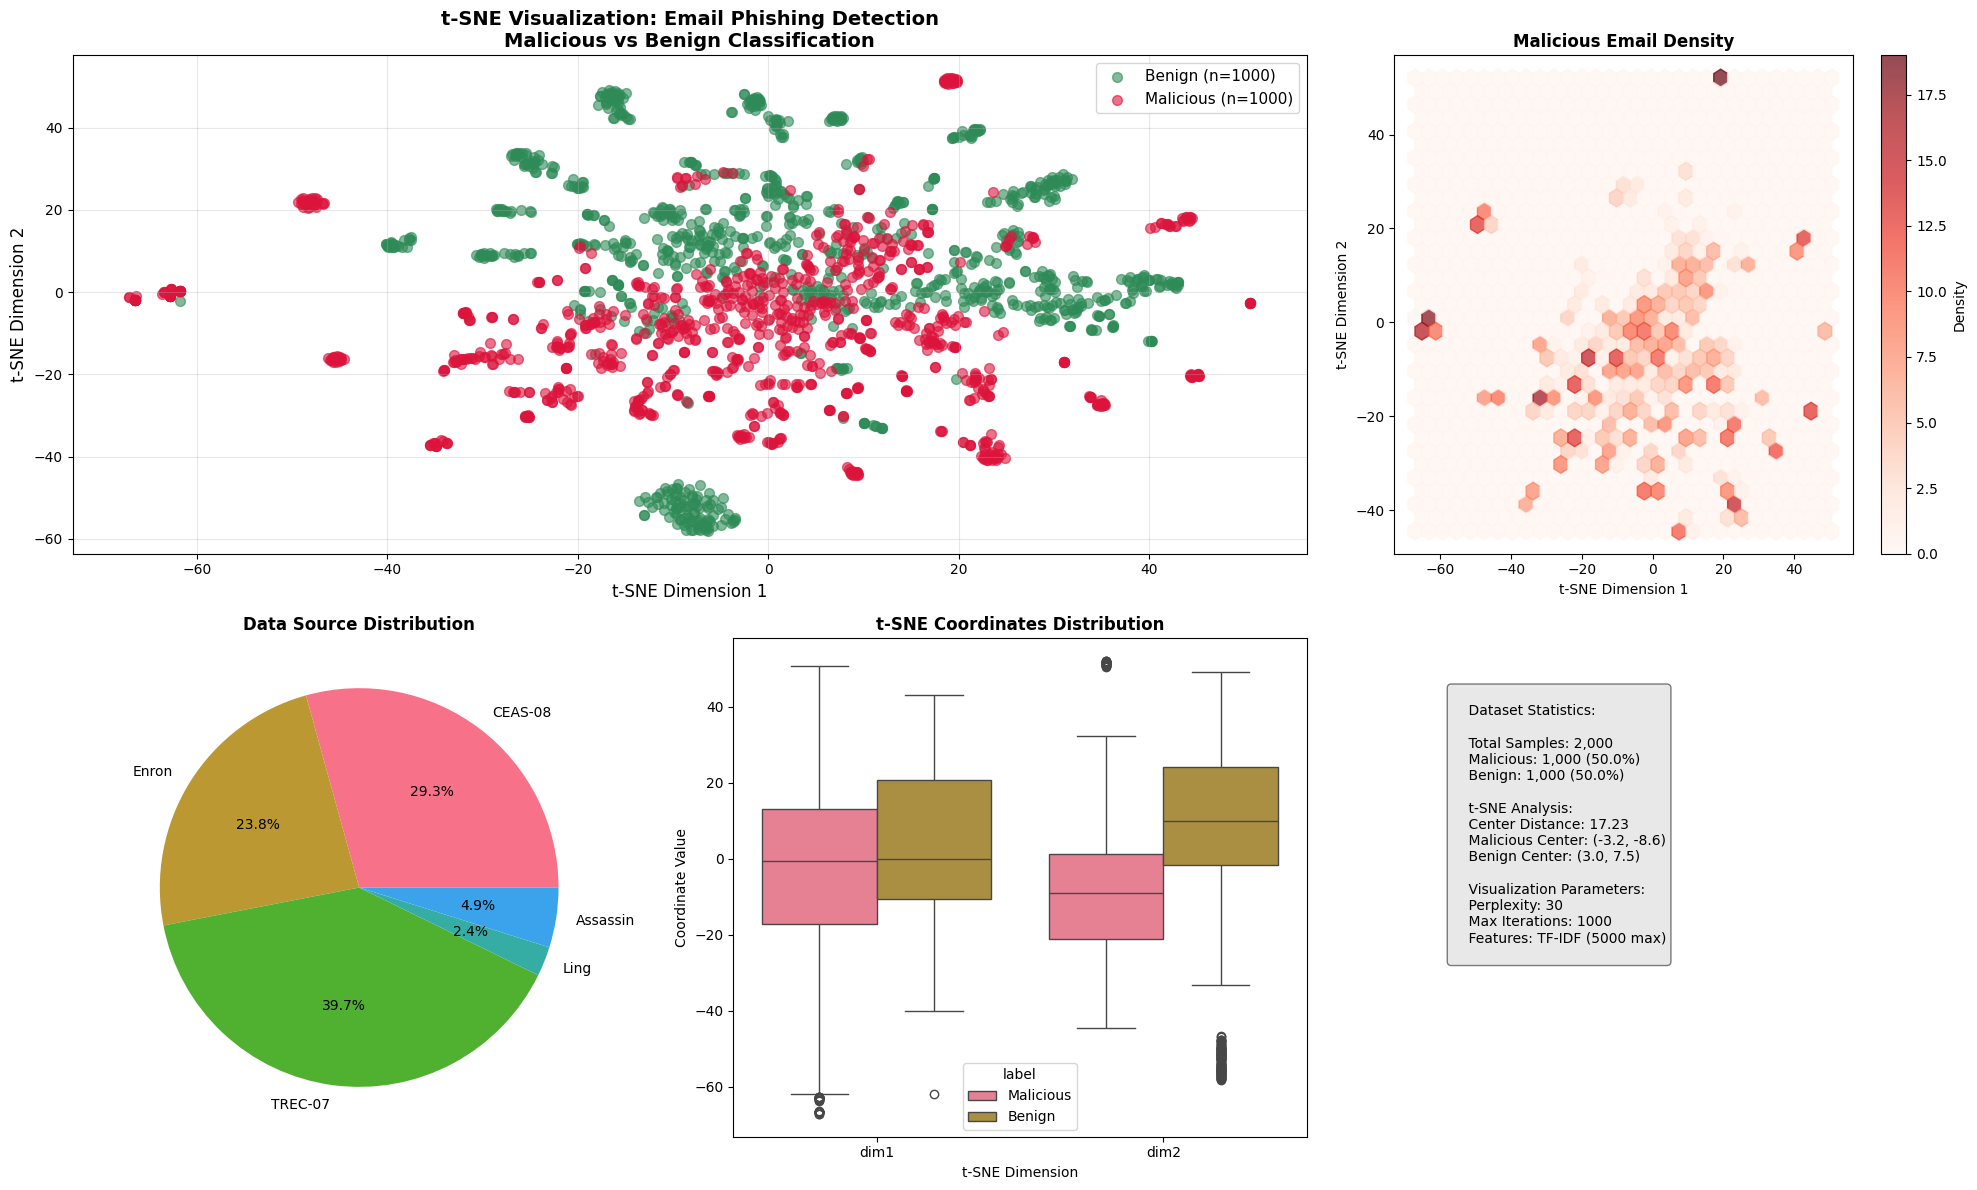


=== Cluster Separation Analysis ===
Centroid Distance: 17.226
Average Malicious Spread: 25.890
Average Benign Spread: 28.729
Separation Ratio: 0.631
❌ Poor separation - significant class overlap

🎉 Visualization complete!
📊 Check the generated plot and saved image file.

=== Sample Point Analysis ===

🔴 Most Isolated Malicious Emails:
1. Subject: CNN.com Daily Top 10
   t-SNE coords: (-66.54, -1.83)

2. Subject: CNN.com Daily Top 10
   t-SNE coords: (-66.54, -1.83)

3. Subject: CNN.com Daily Top 10
   t-SNE coords: (-66.54, -1.83)

4. Subject: CNN.com Daily Top 10
   t-SNE coords: (-67.17, -1.09)

5. Subject: CNN.com Daily Top 10
   t-SNE coords: (-67.17, -1.09)



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

def load_email_data(file_path, sample_size=None):
    """
    Load email phishing data from compressed CSV
    """
    print(f"Loading data from: {file_path}")
    
    try:
        # Load compressed CSV
        with gzip.open(file_path, 'rt', encoding='utf-8') as f:
            df = pd.read_csv(f)
        
        print(f"Original dataset shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")
        
        # Sample data if specified (for performance)
        if sample_size and len(df) > sample_size:
            # Stratified sampling to maintain label distribution
            malicious = df[df['label'] == 1].sample(n=min(sample_size//2, len(df[df['label'] == 1])), random_state=42)
            benign = df[df['label'] == 0].sample(n=min(sample_size//2, len(df[df['label'] == 0])), random_state=42)
            df = pd.concat([malicious, benign]).sample(frac=1, random_state=42).reset_index(drop=True)
            print(f"Sampled dataset shape: {df.shape}")
        
        # Check for missing values
        print(f"\nMissing values:")
        print(df.isnull().sum())
        
        # Fill missing values
        df['subject'] = df['subject'].fillna('')
        df['body'] = df['body'].fillna('')
        
        # Label distribution
        label_dist = df['label'].value_counts()
        print(f"\nLabel distribution:")
        print(f"Benign (0): {label_dist.get(0, 0)} ({label_dist.get(0, 0)/len(df)*100:.1f}%)")
        print(f"Malicious (1): {label_dist.get(1, 0)} ({label_dist.get(1, 0)/len(df)*100:.1f}%)")
        
        return df
    
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def preprocess_text_features(df, max_features=5000, ngram_range=(1, 2)):
    """
    Convert text features to numerical vectors using TF-IDF
    """
    print(f"\nPreprocessing text features...")
    
    # Combine subject and body
    df['combined_text'] = df['subject'].astype(str) + " " + df['body'].astype(str)
    
    # Create TF-IDF vectorizer
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        stop_words='english',
        lowercase=True,
        strip_accents='unicode',
        min_df=2,  # Ignore terms that appear in less than 2 documents
        max_df=0.95  # Ignore terms that appear in more than 95% of documents
    )
    
    # Fit and transform text
    print("Fitting TF-IDF vectorizer...")
    tfidf_matrix = vectorizer.fit_transform(df['combined_text'])
    
    print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
    print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
    
    return tfidf_matrix.toarray(), vectorizer

def apply_dimensionality_reduction(X, method='pca', n_components=50):
    """
    Apply dimensionality reduction before t-SNE for better performance
    """
    print(f"\nApplying {method.upper()} for dimensionality reduction...")
    
    if method == 'pca':
        reducer = PCA(n_components=min(n_components, X.shape[1]))
        X_reduced = reducer.fit_transform(X)
        explained_var = np.sum(reducer.explained_variance_ratio_)
        print(f"PCA explained variance: {explained_var:.3f}")
    else:
        X_reduced = X
    
    print(f"Reduced shape: {X_reduced.shape}")
    return X_reduced

def create_tsne_visualization(X, labels, sources=None, perplexity=30, max_iter=1000):
    """
    Create t-SNE visualization of the data
    """
    print(f"\nRunning t-SNE with perplexity={perplexity}, max_iter={max_iter}...")
    
    # Apply t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        max_iter=max_iter,
        random_state=42,
        learning_rate='auto',
        init='random'
    )
    
    X_tsne = tsne.fit_transform(X)
    
    print("t-SNE completed!")
    return X_tsne

def plot_comprehensive_visualization(X_tsne, labels, sources=None, save_path=None):
    """
    Create comprehensive visualization plots
    """
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 12))
    
    # Main t-SNE plot by label
    ax1 = plt.subplot(2, 3, (1, 2))
    
    # Create scatter plot
    colors = ['#2E8B57', '#DC143C']  # Sea green for benign, Crimson for malicious
    labels_text = ['Benign', 'Malicious']
    
    for i, (label, color, text) in enumerate(zip([0, 1], colors, labels_text)):
        mask = labels == label
        plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                   c=color, alpha=0.6, s=50, label=f'{text} (n={np.sum(mask)})')
    
    plt.title('t-SNE Visualization: Email Phishing Detection\nMalicious vs Benign Classification', 
              fontsize=14, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    # Density plot for malicious samples
    ax2 = plt.subplot(2, 3, 3)
    malicious_mask = labels == 1
    if np.sum(malicious_mask) > 0:
        plt.hexbin(X_tsne[malicious_mask, 0], X_tsne[malicious_mask, 1], 
                   gridsize=30, cmap='Reds', alpha=0.7)
        plt.colorbar(label='Density')
    plt.title('Malicious Email Density', fontsize=12, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1', fontsize=10)
    plt.ylabel('t-SNE Dimension 2', fontsize=10)
    
    # Source distribution (if available)
    ax3 = plt.subplot(2, 3, 4)
    if sources is not None:
        source_counts = Counter(sources)
        plt.pie(source_counts.values(), labels=source_counts.keys(), autopct='%1.1f%%')
        plt.title('Data Source Distribution', fontsize=12, fontweight='bold')
    else:
        # Label distribution pie chart
        label_counts = Counter(labels)
        colors_pie = ['#2E8B57', '#DC143C']
        plt.pie([label_counts[0], label_counts[1]], 
                labels=['Benign', 'Malicious'], 
                colors=colors_pie,
                autopct='%1.1f%%',
                startangle=90)
        plt.title('Label Distribution', fontsize=12, fontweight='bold')
    
    # Box plot of coordinates by label
    ax4 = plt.subplot(2, 3, 5)
    tsne_df = pd.DataFrame({
        'dim1': X_tsne[:, 0],
        'dim2': X_tsne[:, 1],
        'label': ['Malicious' if l == 1 else 'Benign' for l in labels]
    })
    
    melted_df = pd.melt(tsne_df, id_vars=['label'], value_vars=['dim1', 'dim2'])
    sns.boxplot(data=melted_df, x='variable', y='value', hue='label', ax=ax4)
    plt.title('t-SNE Coordinates Distribution', fontsize=12, fontweight='bold')
    plt.xlabel('t-SNE Dimension', fontsize=10)
    plt.ylabel('Coordinate Value', fontsize=10)
    
    # Statistics summary
    ax5 = plt.subplot(2, 3, 6)
    ax5.axis('off')
    
    # Calculate statistics
    total_samples = len(labels)
    malicious_count = np.sum(labels == 1)
    benign_count = np.sum(labels == 0)
    malicious_ratio = malicious_count / total_samples
    
    # Calculate separation metrics
    malicious_center = np.mean(X_tsne[labels == 1], axis=0)
    benign_center = np.mean(X_tsne[labels == 0], axis=0)
    center_distance = np.linalg.norm(malicious_center - benign_center)
    
    stats_text = f"""
    Dataset Statistics:
    
    Total Samples: {total_samples:,}
    Malicious: {malicious_count:,} ({malicious_ratio:.1%})
    Benign: {benign_count:,} ({1-malicious_ratio:.1%})
    
    t-SNE Analysis:
    Center Distance: {center_distance:.2f}
    Malicious Center: ({malicious_center[0]:.1f}, {malicious_center[1]:.1f})
    Benign Center: ({benign_center[0]:.1f}, {benign_center[1]:.1f})
    
    Visualization Parameters:
    Perplexity: 30
    Max Iterations: 1000
    Features: TF-IDF (5000 max)
    """
    
    ax5.text(0.1, 0.9, stats_text, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Visualization saved to: {save_path}")
    
    plt.show()
    
    return fig

def analyze_cluster_separation(X_tsne, labels):
    """
    Analyze how well the classes are separated in t-SNE space
    """
    print(f"\n=== Cluster Separation Analysis ===")
    
    malicious_points = X_tsne[labels == 1]
    benign_points = X_tsne[labels == 0]
    
    # Calculate centroids
    malicious_centroid = np.mean(malicious_points, axis=0)
    benign_centroid = np.mean(benign_points, axis=0)
    
    # Distance between centroids
    centroid_distance = np.linalg.norm(malicious_centroid - benign_centroid)
    
    # Average intra-class distances
    malicious_distances = [np.linalg.norm(point - malicious_centroid) for point in malicious_points]
    benign_distances = [np.linalg.norm(point - benign_centroid) for point in benign_points]
    
    avg_malicious_spread = np.mean(malicious_distances)
    avg_benign_spread = np.mean(benign_distances)
    
    # Separation ratio
    separation_ratio = centroid_distance / ((avg_malicious_spread + avg_benign_spread) / 2)
    
    print(f"Centroid Distance: {centroid_distance:.3f}")
    print(f"Average Malicious Spread: {avg_malicious_spread:.3f}")
    print(f"Average Benign Spread: {avg_benign_spread:.3f}")
    print(f"Separation Ratio: {separation_ratio:.3f}")
    
    if separation_ratio > 2:
        print("✅ Good separation - classes are well-distinguishable")
    elif separation_ratio > 1:
        print("⚠️  Moderate separation - some overlap expected")
    else:
        print("❌ Poor separation - significant class overlap")
    
    return {
        'centroid_distance': centroid_distance,
        'malicious_spread': avg_malicious_spread,
        'benign_spread': avg_benign_spread,
        'separation_ratio': separation_ratio
    }

def main():
    """
    Main function to run the complete visualization pipeline
    """
    # Configuration
    TRAIN_FILE = "../raw/five_email_phishing_train.csv.gz"
    SAMPLE_SIZE = 2000  # Adjust based on your computational resources
    MAX_FEATURES = 5000
    
    print("🔍 Email Phishing Data t-SNE Visualization")
    print("=" * 50)
    
    # Step 1: Load data
    df = load_email_data(TRAIN_FILE, sample_size=SAMPLE_SIZE)
    if df is None:
        return
    
    # Step 2: Preprocess text features
    X_tfidf, vectorizer = preprocess_text_features(df, max_features=MAX_FEATURES)
    
    # Step 3: Dimensionality reduction (optional but recommended for large datasets)
    X_reduced = apply_dimensionality_reduction(X_tfidf, method='pca', n_components=50)
    
    # Step 4: Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_reduced)
    
    # Step 5: Apply t-SNE
    X_tsne = create_tsne_visualization(X_scaled, df['label'].values, perplexity=30)
    
    # Step 6: Create comprehensive visualization
    fig = plot_comprehensive_visualization(
        X_tsne, 
        df['label'].values, 
        sources=df['source'].values if 'source' in df.columns else None,
        save_path="email_phishing_tsne_analysis.png"
    )
    
    # Step 7: Analyze separation
    separation_stats = analyze_cluster_separation(X_tsne, df['label'].values)
    
    print(f"\n🎉 Visualization complete!")
    print(f"📊 Check the generated plot and saved image file.")
    
    return X_tsne, df, separation_stats

# Interactive analysis functions
def explore_sample_points(X_tsne, df, n_samples=5):
    """
    Explore specific points in the t-SNE visualization
    """
    print(f"\n=== Sample Point Analysis ===")
    
    # Find extreme points
    malicious_mask = df['label'] == 1
    benign_mask = df['label'] == 0
    
    # Most isolated malicious points
    if np.sum(malicious_mask) > 0:
        malicious_points = X_tsne[malicious_mask]
        malicious_indices = np.where(malicious_mask)[0]
        
        # Find points furthest from benign center
        benign_center = np.mean(X_tsne[benign_mask], axis=0) if np.sum(benign_mask) > 0 else np.array([0, 0])
        distances = [np.linalg.norm(point - benign_center) for point in malicious_points]
        furthest_indices = np.argsort(distances)[-n_samples:]
        
        print(f"\n🔴 Most Isolated Malicious Emails:")
        for i, idx in enumerate(furthest_indices):
            original_idx = malicious_indices[idx]
            subject = df.loc[original_idx, 'subject'][:100] + "..." if len(df.loc[original_idx, 'subject']) > 100 else df.loc[original_idx, 'subject']
            print(f"{i+1}. Subject: {subject}")
            print(f"   t-SNE coords: ({X_tsne[original_idx, 0]:.2f}, {X_tsne[original_idx, 1]:.2f})")
            print()

if __name__ == "__main__":
    # Run the main analysis
    X_tsne, df, stats = main()
    
    # Optional: Explore sample points
    if 'df' in locals():
        explore_sample_points(X_tsne, df)